In [1]:
from itertools import product
from typing import Any, Dict, Iterable
from datetime import datetime

from sklearn.metrics import mean_squared_error
from configs.config_loader import load_config
from model.neural_net import PhysicsInformedNN
import pandas as pd
import numpy as np
import os
import re
import tensorflow as tf
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import os

2025-04-16 10:39:09.504873: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744792749.558206   23827 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744792749.577274   23827 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-16 10:39:09.635797: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
NUM_SAMPLES = 500

config_base = load_config('configs/default.yaml')

config = config_base
config["activation"] = "swish"
config["N_hidden"] = 4
config["N_neurons"] = 50
config["N_epochs"] = 25000
config["T"] = 12.5
config["freq_save"] = 0


version : default
seed : 1
x0 : 0.0
y0 : 0.5
T : 15.0
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 25000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss']
freq_save : 100
regularization : reg_derivative_unstable_fp
reg_coeff : 1.0
reg_decay : linear
reg_epochs : 0.5
eps : 0.01


In [ ]:
x0s = np.random.uniform(-1, 4, size=NUM_SAMPLES)
y0s = np.random.uniform(-1, 4, size=NUM_SAMPLES)


plt.scatter(x0s, y0s)
plt.show()

dirname_no_reg = f"logs/models/visualization_experiments/no_reg"
if not os.path.exists(dirname_no_reg):
    os.makedirs(dirname_no_reg)

dirname_reg_derivative = f"logs/models/visualization_experiments/reg_derivative"
if not os.path.exists(dirname_reg_derivative):
    os.makedirs(dirname_reg_derivative)

dirname_reg_derivative_unstable_fp = f"logs/models/visualization_experiments/reg_derivative_unstable_fp"
if not os.path.exists(dirname_reg_derivative_unstable_fp):
    os.makedirs(dirname_reg_derivative_unstable_fp)

results_list = []

for i in range(NUM_SAMPLES):
    config["x0"] = float(x0s[i])
    config["y0"] = float(y0s[i])
    
    try:
        # Without regularization
        config["regularizer"] = "no_reg"
        PINN = PhysicsInformedNN(config, verbose=True)
        training_log = PINN.train()

        PINN.save_weights(f"{dirname_no_reg}/run_{i}.pkl")

        t_line, x_true, y_true = PINN.data.reference()

        # get PINN prediction
        x_pred = PINN(t_line)
        loss = mean_squared_error(x_true.numpy(), x_pred.numpy())
        loss_success_no_reg = (np.linalg.norm(x_true - x_pred) / np.linalg.norm(x_true)) < 0.15



        # With time derivative regularization
        config["regularizer"] = "reg_derivative"
        config["reg_coeff"] = 1.0
        config["reg_epochs"] = 0.5
        config["reg_decay"] = "linear"
        PINN = PhysicsInformedNN(config, verbose=True)
        training_log = PINN.train()

        PINN.save_weights(f"{dirname_reg_derivative}/run_{i}.pkl")

        # get PINN prediction
        x_pred = PINN(t_line)
        loss = mean_squared_error(x_true.numpy(), x_pred.numpy())
        loss_success_reg_derivative = (np.linalg.norm(x_true - x_pred) / np.linalg.norm(x_true)) < 0.15


        # With unstable fp regularization
        config["regularizer"] = "reg_derivative_unstable_fp"
        config["reg_coeff"] = 1.0
        config["reg_epochs"] = 0.5
        config["reg_decay"] = "linear"
        PINN = PhysicsInformedNN(config, verbose=True)
        training_log = PINN.train()
        
        PINN.save_weights(f"{dirname_reg_derivative_unstable_fp}/run_{i}.pkl")
        
        # get PINN prediction
        x_pred = PINN(t_line)
        loss = mean_squared_error(x_true.numpy(), x_pred.numpy())
        loss_success_reg_derivative_unstable_fp = (np.linalg.norm(x_true - x_pred) / np.linalg.norm(x_true)) < 0.15

        table_entry = pd.DataFrame({"(x0, y0)": [(float(x0s[i]), float(y0s[i]))], 
                                    "success_no_reg": [loss_success_no_reg],
                                    "success_reg_derivative": [loss_success_reg_derivative],
                                    "success_reg_derivative_unstable_fp": [loss_success_reg_derivative_unstable_fp]})
        
        results_list.append(table_entry)
        results_table = pd.concat(results_list)
        results_table.to_csv("visual_results.csv")

    except Exception as e:
        print(e)
            
     

version : default
seed : 1
x0 : 0.0
y0 : 0.5
T : 15.0
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 25000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss']
freq_save : 100
regularization : reg_derivative_unstable_fp
reg_coeff : 1.0
reg_decay : linear
reg_epochs : 0.5
eps : 0.01
*** PINN build & initialized ***


/home/mbabic/Desktop/PINNs_fixed_points/env/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN b

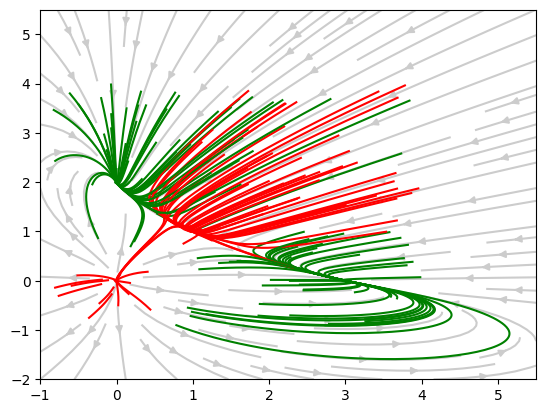

*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN build & initialized ***
*** PINN b

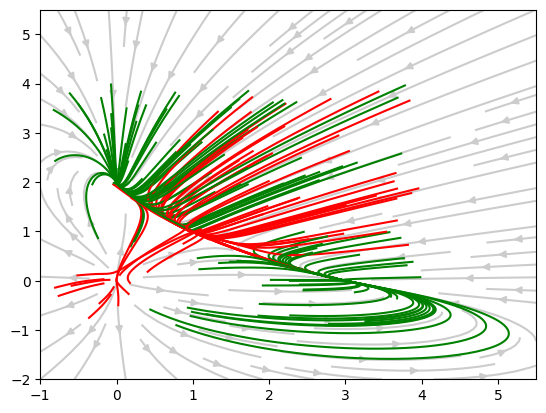

In [5]:
from configs.config_loader import load_config
from model.neural_net import PhysicsInformedNN


config = load_config('configs/default.yaml')
config["T"] = 15.0
PINN = PhysicsInformedNN(config)

results_table = pd.read_csv("visual_results.csv")
results_table["x0"] = results_table["(x0, y0)"].apply(lambda row: eval(row)[0])
results_table["y0"] = results_table["(x0, y0)"].apply(lambda row: eval(row)[1])

colors = {True: "green", False: "red"}
xscale, yscale, n_arrows = 1.2, 2, 20
x = np.linspace(-1, 5.5, n_arrows)
x_t = np.linspace(-2, 5.5, n_arrows)
XX, YY = np.meshgrid(x, x_t)
Y = np.vstack([XX.flatten(), YY.flatten()])
t = np.zeros(len(Y))
[dx, dy] = PINN.data.diff_equations(t, Y)
x, y = XX.flatten(), YY.flatten()

plt.figure()
plt.streamplot(XX, YY, dx.reshape(XX.shape), dy.reshape(YY.shape), color='0.8', zorder=0)

for i in range(results_table.shape[0]):
    config["x0"] = float(results_table["x0"].iloc[i])
    config["y0"] = float(results_table["y0"].iloc[i])
    PINN = PhysicsInformedNN(config)
    PINN.load_weights(PINN.log_path.joinpath(f"models/visualization_experiments/no_reg/run_{i}.pkl"))
    t_line, x_true, y_true = PINN.data.reference()
    xy_pred = PINN(t_line)
    x_pred = xy_pred[:, 0]
    y_pred = xy_pred[:, 1]
    color = 'green' if results_table["success_no_reg"].iloc[i] else "red"
    plt.plot(x_pred, y_pred, color=color)

plt.show()




plt.figure()
plt.streamplot(XX, YY, dx.reshape(XX.shape), dy.reshape(YY.shape), color='0.8', zorder=0)

for i in range(results_table.shape[0]):
    config["x0"] = float(results_table["x0"].iloc[i])
    config["y0"] = float(results_table["y0"].iloc[i])
    PINN = PhysicsInformedNN(config)
    PINN.load_weights(f"logs/models/visualization_experiments/reg_derivative_unstable_fp/run_{i}.pkl")
    t_line, x_true, y_true = PINN.data.reference()
    xy_pred = PINN(t_line)
    x_pred = xy_pred[:, 0]
    y_pred = xy_pred[:, 1]
    color = 'green' if results_table["success_reg_derivative_unstable_fp"].iloc[i] else "red"
    plt.plot(x_pred, y_pred, color=color)

plt.show()
